## Part 1b of the Intro to Neural Networks and Backpropagation
Part two uses code built in p1, but with some cleanup

In [25]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from graphviz import Digraph



# Test it:
%matplotlib inline

In [26]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = '') -> None:
        self.data = data
        self.grad = 0.0 # gradient is the value of a partial derivative of output value in respect to this value
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self) -> str:
        return f"Value(data={self.data}, op={self._op if self._op else 'NOP'} [{self.label}])"

    def __add__(self, other) -> "Value":
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other

    def __mul__(self, other) -> "Value":
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only supporting int/float powers"
        out = Value(self.data ** other, (self,), f"**{other}")
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out


    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other):
        return self * other ** -1

    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        def _backward():
            self.grad += (1 - (t ** 2)) * out.grad

        out = Value(t, (self, ), _op = 'tanh')
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data 
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad # since derivative of e ** x is e ** x
        out._backward = _backward
        return out
    
    def backward(self):
        visited = set()
        ar = []
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                ar.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(ar):
            node._backward()


In [27]:
def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [28]:
# inputs x1 x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1 w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias b
b = Value(6.8813735870195432, label='b')
x1w1 = x1 * w1;x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
# sum to be fed into activation function n
n = x1w1x2w2 + b;n.label='n'
# output o
o = n.tanh();o.label = 'o'


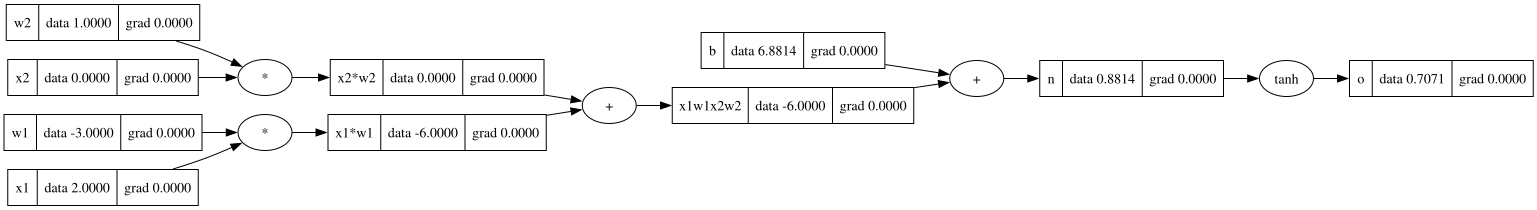

In [29]:
draw_dot(o)

## breaking up a tanh, exercising with more operations

In [30]:
# added wrappers into value to be able to perform Value(3) + 3, Value(3) * 3, plus added rmul and radd
v1 = Value(15)
print(v1 + 3)
print(v1 * 3)
print(3 * v1)
print(3 + v1)

# implemented exp method
print(v1.exp())

# implementing division
# notice that:
# a / b = a * (1 / b) = a * (b ** -1)
# so division could be implemented through exponentiation and multiplication
# for that we implemented __pow__ and __truediv__
v2 = Value(9)
print(v2 ** 3)
v3 = Value(3)
print(v2 / v3)

# to support subtraction, implemented __neg__ and __sub__
print (v2 - v3)
print(v2 - 3)
print(-v3)

Value(data=18, op=+ [])
Value(data=45, op=* [])
Value(data=45, op=* [])
Value(data=18, op=+ [])
Value(data=3269017.3724721107, op=exp [])
Value(data=729, op=**3 [])
Value(data=3.0, op=* [])
Value(data=6, op=+ [])
Value(data=6, op=+ [])
Value(data=-3, op=* [])


In [31]:
# now lets stop using tanh, but start using new exp methods
# inputs x1 x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1 w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias b
b = Value(6.8813735870195432, label='b')
x1w1 = x1 * w1;x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
# sum to be fed into activation function n
n = x1w1x2w2 + b;n.label='n'
# output o
e = (2 * n).exp();e.label = 'e'
o = (e - 1) / (e + 1)
o.label = 'o'
o.backward()


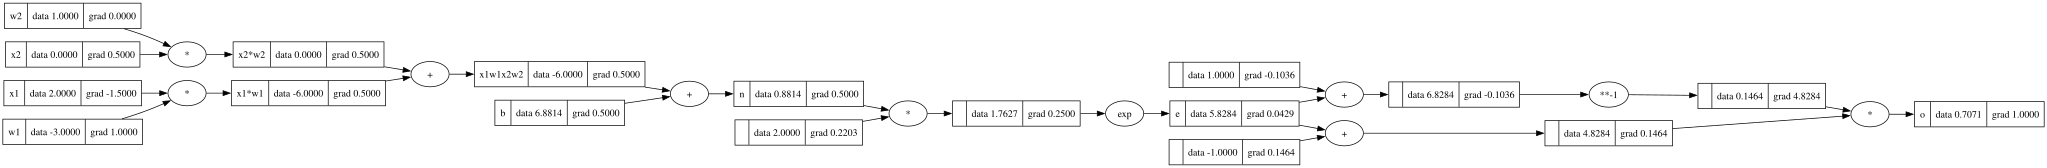

In [32]:
draw_dot(o)

## Doing the same but in pytorch: comparison


In [33]:
import torch

# by default tensor type is float32, we cast it to double to be consistent with micrograd data types
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()
print("----")
print("x2.grad.item()", x2.grad.item())
print("w2.grad.item()", w2.grad.item())
print("x1.grad.item()", x1.grad.item())
print("w1.grad.item()", w1.grad.item())



0.7071066904050358
----
x2.grad.item() 0.5000001283844369
w2.grad.item() 0.0
x1.grad.item() -1.5000003851533106
w1.grad.item() 1.0000002567688737


## Building our neural net library (multi-layer perceptron) in micrograd

In [34]:
from typing import Any


class Neuron:
     def __init__(self, nin) -> None:
          self.nin = nin
          self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
          self.b = Value(random.uniform(-1, 1))

     def __call__(self, x):
          # w * x + b
          # zip takes two list or iterators and creates tuples with element from every list 
          # ie (i1_0,i2_0), (i1_1, i2_1), (i1_2, i2_2), etc
          act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)

          out = act.tanh()
          # print(f"neuron[{self.nin}]", x, out)
          return out
     
     def parameters(self):
          return self.w + [self.b]
     
class Layer:
     def __init__(self, nin, nout) -> None:
          self.nin = nin
          self.nout = nout
          self.neurons = [Neuron(nin) for _ in range(nout)]
     
     def __call__(self, x):
          outs = [n(x) for n in self.neurons]
          r = outs[0] if len(outs) == 1 else outs
          # print(f"layer[{self.nin}:{self.nout}]", x, r)
          return r
     
     def parameters(self):
          # params = []
          # for n in self.neurons:
          #      params.extend(n.parameters())
          # return params
          return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
     # nouts is a list, where each element is a size of a layer
     def __init__(self, nin, nouts) -> None:
          sz = [nin] + nouts
          self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]
     
     def __call__(self, x):
          # print("MLP", x)
          for layer in self.layers:
               x = layer(x)
          return x

     def parameters(self):
          # params = []
          # for n in self.layers:
          #      params.extend(n.parameters())
          # return params
          return [p for layer in self.layers for p in layer.parameters()]



     
x = (2.0, 3.0)
n = Neuron(2)
print(n(x))

x = (2.0, 3.0)
n = Layer(2, 3)
print(n(x))

x = (2.0, 3.0, -1)
n = MLP(3, [4, 4, 1])
print(n(x))


Value(data=0.689220600741307, op=tanh [])
[Value(data=-0.9345858003338532, op=tanh []), Value(data=-0.9943964685517603, op=tanh []), Value(data=0.9251235358975552, op=tanh [])]
Value(data=-0.03649400747634589, op=tanh [])


In [35]:
# draw_dot(n(x))

## Creating a tiny dataset, writing the loss function

In [36]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

x = (2.0, 3.0, -1)
n = MLP(3, [4, 4, 1])
print(n(x))

ypred = [n(x) for x in xs]
print(ypred)



Value(data=-0.5457267098746525, op=tanh [])
[Value(data=-0.5457267098746525, op=tanh []), Value(data=-0.23009512036631743, op=tanh []), Value(data=-0.38725730887410026, op=tanh []), Value(data=-0.4922819116251359, op=tanh [])]


In [37]:
# loss is a single number that measures how well the neural net is performing

loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]) # type: ignore
print(loss)
loss.backward()  # type: ignore
print(n.layers[0].neurons[0].w[0].grad)
print(n.layers[0].neurons[0].w[0].data)

Value(data=5.584383494595453, op=+ [])
0.05501964404191858
-0.9148006508626125


## doing gradient descent manually

In [38]:
for p in n.parameters():
    p.data += -0.01 * p.grad
print(n.layers[0].neurons[0].w[0].data)

-0.9153508473030317


In [39]:
ypred = [n(x) for x in xs]
print(ypred)
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]) # type: ignore
print(loss)


[Value(data=-0.4392417320471932, op=tanh []), Value(data=-0.2182949444618358, op=tanh []), Value(data=-0.3593514906600886, op=tanh []), Value(data=-0.3898648156707661, op=tanh [])]
Value(data=5.024634275479112, op=+ [])


In [40]:
# full loop for gradient descent
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

x = (2.0, 3.0, -1)
n = MLP(3, [4, 4, 1])
print(n(x))

for i in range(10):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) # type: ignore
    #print(f"{loss.data:.4f}")  # type: ignore
   
    # backward pass
    for p in n.parameters():
        p.grad = 0
    loss.backward() # type: ignore

    for p in n.parameters():
        p.data += -0.05 * p.grad

# n.parameters()
# lets type type type type type type type okay again again again lets keep typing typing typing okay okay okay o


Value(data=0.4420746967368993, op=tanh [])


In [41]:
# full loop for gradient descent
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

x = (2.0, 3.0, -1)
n = MLP(3, [4, 4, 1])

for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)


0 4.224734964732757
1 6.675651824698861
2 1.8818393046661221
3 1.4386424959652389
4 1.4799148016704717
5 1.1187020252690716
6 0.060532057035426357
7 0.04460816909906522
8 0.03631483275589112
9 0.031096722387926837
10 0.027450231665215048
11 0.024723267404025046
12 0.022584975661631278
13 0.02084890534444792
14 0.019401636028271746
15 0.018169996709760994
16 0.017104515095127136
17 0.01617042965080878
18 0.015342515947334802
19 0.014601962584992372
